# Automating the selection of the number of replications

An implementation of the "replications algorithm" from [Hoad, Robinson, & Davies (2010)](https://www.jstor.org/stable/40926090). Given a performance measure, and a user set CI half width precision, automatically select the number of replications.

Combines the "confidence interval" method for selecting the number of replications with a sequential look-ahead procedure to determine if a desired precision in CI is maintained given more replication.

> If you make use of the code in your work **please cite the GitHub repository and also the original authors article**:
>> Hoad, Robinson, & Davies (2010). Automated selection of the number of replications for a discrete-event simulation. *Journal of the Operational Research Society*. [https://www.jstor.org/stable/40926090](https://www.jstor.org/stable/40926090)

## Imports

> Note: to run this notebook you will need to modify `hds_stoch`
> pip install`plotly` and `treat-sim`
> conda install -c conda-forge sim-tools=0.7.0


In [1]:
import numpy as np
import pandas as pd
from typing import Optional
import warnings

## Simulation model

We will make use of one of my example `simpy` models `treat-sim` that [can be installed from PyPI](https://pypi.org/project/treat-sim/)

```bash
pip install treat-sim
```

You can read more about the model on PyPI and on the [GitHub repo](ttps://github.com/pythonhealthdatascience/stars-treat-sim)

> The model is **terminating system** based on on exercise 13 from Nelson (2013) page 170.
>> Nelson. B.L. (2013). Foundations and methods of stochastic simulation. Springer.


In [2]:
from treat_sim.model import Scenario, single_run, multiple_replications
from rep_utility import (
    plotly_confidence_interval_method,
    confidence_interval_method,
)

## Running a replication of the model

To run the model you need to create an instance of `Scenario`. An instance of `Scenario` contains all of the parameters to use in the model (e.g. resources and statistical distributions for arrivals and activities). A default scenario is created like so:

In [3]:
scenario = Scenario()

Pass in optional parameters to run a different scenario

In [4]:
new_scenario = Scenario(n_triage=4, n_exam=5, exam_mean=10.0, trauma_mean=6.0)

To run a replication of the model use the `single_run` function. You need to pass in an instance of `Scenario`.  The model uses common random number streams. To set the random numbers used change the `random_no_set` parameter

In [5]:
results = single_run(scenario, random_no_set=1)
results.T

rep,1
00_arrivals,227.000000
01a_triage_wait,57.120114
01b_triage_util,0.621348
02a_registration_wait,90.002385
02b_registration_util,0.836685
03a_examination_wait,14.688492
03b_examination_util,0.847295
04a_treatment_wait(non_trauma),120.245474
04b_treatment_util(non_trauma),0.912127
05_total_time(non-trauma),233.882040


## The classical "Confidence Interval Method"

1. Select a desired precision: % deviation of the interval from the mean (half width / cumulative mean). E.g. 0.1
2. Run a large number of replications
3. Identify where the precision of the interval falls below desired precision.
4. Repeat for all performance measures and select the highest number of replications.

A confidence interval is calculated as:

$$ CI = \overline{X} \pm t_{n-1, \alpha/2} \dfrac{S}{\sqrt{n}}$$


where: 

* $\overline{X}$ = mean of the output data from the replications
* $S$ = standard deviation of the output data from the replications
* $n$ = the number of replications
* $t_{n-1, \alpha/2}$ = value from the *t*-distribution with $n-1$ degrees of freedom and a significance level of $\alpha/2$


**Downsides of the classical approach**

1. We may need to choose a large initial number of replications - or else risk not running enough replication to hit the precision target
2. A more minor issue is that the amount of replication we run may be overkill
3. The real issue is if we want to automate analysis. The process is clunky and manual. First we run replications. Then we analyse. In its current form, we cannot embed the process into an automated analysis pipeline.

Here is an example:

In [6]:
# run a large number of replications
replication_results = multiple_replications(scenario, n_reps=150)

In [7]:
# identify where precision falls below target
n_reps, conf_ints = confidence_interval_method(
    replication_results["07a_treatment_wait(trauma)"].to_numpy(),
    desired_precision=0.1,
)

/home/tom/Documents/code/stochastic_systems/labs/simulation/lab6/replications_algorithm/rep_utility.py:318: UserWarning: WARNING: the replications do not reach desired precision
  warnings.warn(message)


In [8]:
# number of reps
n_reps

-1

In [9]:
conf_ints.tail()

,Mean,Cumulative Mean,Standard Deviation,Lower Interval,Upper Interval,% deviation
replications,,,,,,
146,8.87,17.29,14.19,14.97,19.61,0.13
147,7.93,17.22,14.16,14.91,19.53,0.13
148,27.11,17.29,14.13,14.99,19.58,0.13
149,12.44,17.26,14.09,14.98,19.54,0.13
150,8.99,17.20,14.06,14.93,19.47,0.13


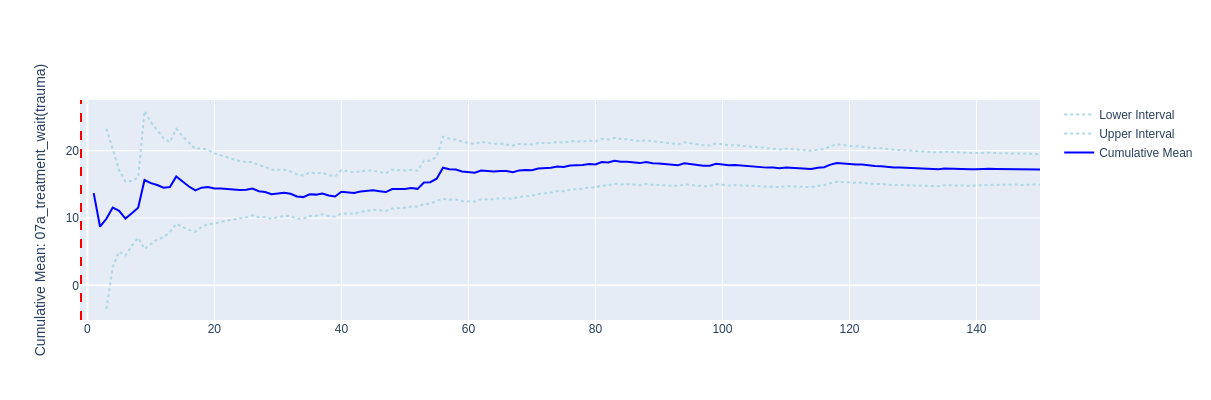

In [10]:
plotly_confidence_interval_method(
    n_reps, conf_ints, metric_name="07a_treatment_wait(trauma)"
)

145


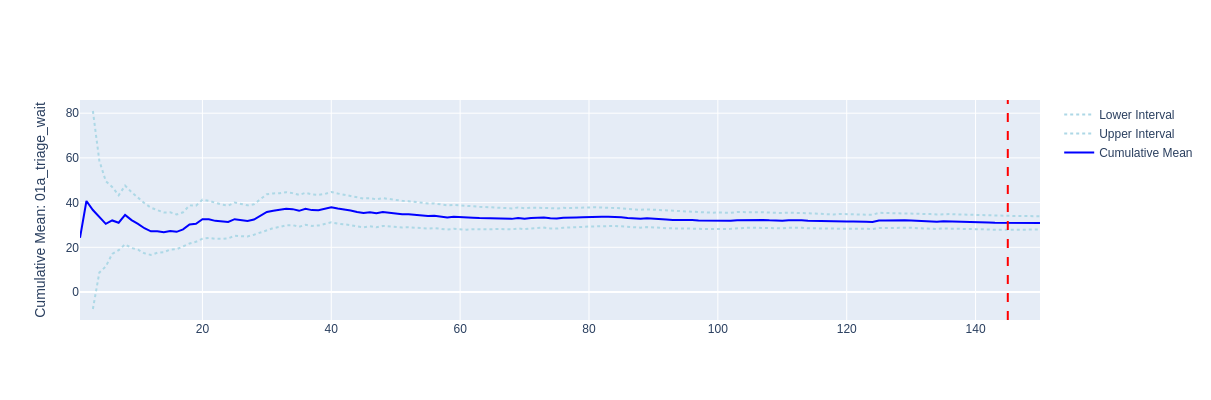

In [11]:
# repeat for a 2nd performance measure
n_reps, conf_ints = confidence_interval_method(
    replication_results["01a_triage_wait"].to_numpy(),
    desired_precision=0.1,
    decimal_places=5,
)

print(n_reps)

plotly_confidence_interval_method(
    n_reps, conf_ints, metric_name="01a_triage_wait"
)

You can also view the CI method in tabular form

In [12]:
conf_ints.head()

,Mean,Cumulative Mean,Standard Deviation,Lower Interval,Upper Interval,% deviation
replications,,,,,,
1,24.28094,24.28094,NaN,NaN,NaN,NaN
2,57.12011,40.70053,NaN,NaN,NaN,NaN
3,28.65938,36.68681,17.83066,-7.60701,80.98063,1.20735
4,24.80139,33.71546,15.72485,8.69372,58.73720,0.74214
5,17.67916,30.50820,15.39109,11.39763,49.61876,0.62641


## Analysing a model using a sequential algorithm

`treat-sim` has been designed so that it is possible to run individual replications of the model as desired. This could be in a sequential manner as we saw above or in a batch (for example the replications algorithm requires 3 initial replications.

The `single_run` function returns a `pandas.DataFrame` (a single row).  We can access a single performance measure like so:

```python
single_run(scenario, random_no_set=rep)["01a_triage_wait"].iloc[0]
```

In [13]:
initial_results = [
    single_run(scenario, random_no_set=rep)["01a_triage_wait"].iloc[0]
    for rep in range(3)
]

np.asarray(initial_results)

array([24.28094341, 57.12011429, 28.65938298])

##  Replications Algorithm overview

The look ahead component is governed by the formula below. A user specifies a look ahead period called $k_{limit}$. If $n \leq 100$ then a parameter $k_{limit}$ is used.  Hoad et al.(2010) reco~mmend a value of 5 based on extensive empirical work. If $n \geq 100$ then a fraction is returned.  The notation $\lfloor$ and $\rfloor$ mean that the function must return an integer value (as it represents the number of replications to look ahead).   

$f(k_{limit}, n) = \Biggl \lfloor \dfrac{k_{limit}}{100}\max(n, 100)\Biggr \rfloor $

In general $f(k_{limit}, n)$ means that as the number of replications increases so does the look ahead period.  For example when you have run 50 replications a $k_{limit} = 5$ means you simulate an extra 5 replications.  When you have run 800 replications a $k_{limit} = 5$ means you simulate an extra $\Biggl \lfloor \dfrac{5}{100} \times 800\Biggr \rfloor = 40$ replications.

The paper provides a formal algorithm notation. Here we provide a pictorial representation of the general logic of the replications algorithm.


<div>
<img src="images/replications_algorithm.png" width="1500"/>
</div>

## Algorithm implementation

### Calculating the cumulative mean and CIs of a replication sequentially

The replications algorithm is **sequential**. This means that we update the mean, confidence intervals and achieved precision iteratively. We will first create a class called `OnlineStatistics` that will handle these computations for us. It uses **Welford's method** for computing and online means and its variance. Here "online" refers to a statistic that is computed via updates to its value as opposed to storing lots of data and repeatedly take the mean after new values have been added).


#### Additional imports to make coding the algorithm

In [14]:
from rep_utility import (
    OnlineStatistics,
    ReplicationTabulizer,
    ReplicationObserver,
)

### Example usage of `OnlineStatistics`

Here we will pass in the initial results, run one more replication and then update.

In [15]:
observer = ReplicationTabulizer()
stats = OnlineStatistics(data=np.array(initial_results), observer=observer)
print(stats.mean)
print(stats.deviation)

36.68681356082355
0.8193652873615882


In [16]:
# we use random no set = 3 so we get different results from the initial 3 reps
x_i = single_run(scenario, random_no_set=3)["01a_triage_wait"].iloc[0]
print(x_i)

24.801392233939637


In [17]:
stats.update(x_i)
print(stats.mean)
print(stats.deviation)

33.71545822910257
0.5488028713220751


In [18]:
x_i = single_run(scenario, random_no_set=4)["01a_triage_wait"].iloc[0]
stats.update(x_i)
print(stats.mean)
print(stats.deviation)

30.508197779201573
0.4809765125078102


In [19]:
observer.summary_table()

,Mean,Cumulative Mean,Standard Deviation,Lower Interval,Upper Interval,% deviation
replications,,,,,,
1,24.280943,24.280943,NaN,NaN,NaN,NaN
2,57.120114,40.700529,NaN,NaN,NaN,NaN
3,28.659383,36.686814,17.830662,6.626912,66.746715,0.819365
4,24.801392,33.715458,15.724847,15.212318,52.218599,0.548803
5,17.679156,30.508198,15.391092,15.834471,45.181924,0.480977


### Replications Algorithm class

In [20]:
class ReplicationsAlgorithm:
    """
    An implementation of the "Replications Algorithm" from
    Hoad, Robinson, & Davies (2010).

    Given a performance measure, and a user set CI half width precision
    automatically select the number of replications.

    Combines the "confidence intervals" method with a sequential look-ahead
    procedure to determine if a desired precision in CI is maintained when
    achieved.

    Sources:
    -------

    Please cite the authors of the algorthim if you use it in your work.

    Hoad, Robinson, & Davies (2010). Automated selection of the number of
    replications for a discrete-event simulation. Journal of the Operational
    Research Society. https://www.jstor.org/stable/40926090

    the code is MIT so please use, but also please cite our respository!
    """

    def __init__(
        self,
        alpha: Optional[float] = 0.05,
        half_width_precision: Optional[float] = 0.1,
        initial_replications: Optional[int] = 3,
        look_ahead: Optional[int] = 5,
        replication_budget: Optional[float] = 1000,
        verbose: Optional[bool] = False,
        observer: Optional[ReplicationObserver] = None,
    ):
        """
        Initiatise the replications algorithm

        Parameters:
        ----------
        alpha: float, optional (default = 0.05)
            Used to construct the 100(1-alpha) CI

        half_width_precision: float, optional (default = 0.1)
            The target half width precision for the algorithm
            % deviation of the interval from mean.

        look_ahead: int, optional (default = 5)
            Recommended no. replications to look ahead to assess stability
            of precision.  When the number of replications n <= 100 the
            value of look ahead is used. When n > 100 then
            look_ahead / 100 * max(n, 100) is used.

        replication_budget: int, optional (default = 1000)
            A hard limit on the number of replications. Use for larger models
            where replication runtime is a constraint.

        verbose: bool, optional (default=False)
            Display the current replication number while running

        observer: ReplicationObserver, optional (default=None)
            Include an observer object to track how statistics change as the
            algorithm runs. For example ReplicationTabuliser to return a table
            equivalent to confidence_interval_method.
        """
        self.alpha = alpha
        self.half_width_precision = half_width_precision
        self.initial_replications = initial_replications
        # look ahead when n < 100
        self.look_ahead = look_ahead

        # hard constraint will terminate alg...
        self.replication_budget = replication_budget

        # show current replication no.
        self.verbose = verbose

        # observer pattern for the metrics over replications
        self.observer = observer

        # current replication number
        self.n = self.initial_replications
        # Nsol
        self._n_solution = self.replication_budget

    def _klimit(self) -> int:
        """
        Return the current look ahead.
        if n <= 100 then return kLimit.  If n > 100 then compute kLimit
        as fraction of n
        """
        return int((self.look_ahead / 100) * max(self.n, 100))

    def select(self, scenario: Scenario, metric: str) -> int:

        converged = False

        # run initial replications of model
        x_i = [
            single_run(scenario, random_no_set=rep)[metric].iloc[0]
            for rep in range(self.initial_replications)
        ]

        # initialise running mean and std dev
        self.stats = OnlineStatistics(
            data=np.array(x_i), alpha=self.alpha, observer=self.observer
        )

        while not converged and self.n <= self.replication_budget:
            if self.n > self.initial_replications:
                # update X_n and d_req
                self.stats.update(x_i)

            # precision achieved?
            if self.stats.deviation <= self.half_width_precision:

                # store current solution
                self._n_solution = self.n
                converged = True

                if self._klimit() > 0:
                    k = 1

                    # look ahead loop
                    while converged and k <= self._klimit():
                        if self.verbose:
                            print(f"{self.n+k}", end=", ")

                        # simulate replication n + k
                        x_i = single_run(
                            scenario, random_no_set=self.n + k - 1
                        )[metric].iloc[0]

                        # update X_n and d_req
                        self.stats.update(x_i)

                        # check new precision
                        if self.stats.deviation > self.half_width_precision:
                            # precision not maintained
                            converged = False
                            self.n += k
                        else:
                            k += 1

                # terminate if precision maintained over lookahead
                if converged:
                    return self._n_solution

            # precision not achieved/maintained so simulate another replication
            self.n += 1
            if self.verbose:
                print(f"{self.n}", end=", ")

            x_i = single_run(scenario, random_no_set=self.n - 1)[metric].iloc[
                0
            ]

        # if code gets to here then no solution found within budget.
        warnings.warn(
            f"Algorithm did not converge for '{metric}'. "
            + "Returning replication budget as solution"
        )
        return self._n_solution

## Running the algorithm for a single metric

In [21]:
results.columns.tolist()

['00_arrivals',
 '01a_triage_wait',
 '01b_triage_util',
 '02a_registration_wait',
 '02b_registration_util',
 '03a_examination_wait',
 '03b_examination_util',
 '04a_treatment_wait(non_trauma)',
 '04b_treatment_util(non_trauma)',
 '05_total_time(non-trauma)',
 '06a_trauma_wait',
 '06b_trauma_util',
 '07a_treatment_wait(trauma)',
 '07b_treatment_util(trauma)',
 '08_total_time(trauma)',
 '09_throughput']

In [22]:
# a default scenario
scenario = Scenario()

observer = ReplicationTabulizer()
analyser = ReplicationsAlgorithm(verbose=False, observer=observer)
n_reps = analyser.select(scenario, "07a_treatment_wait(trauma)")
n_reps

219

In [23]:
observer.summary_table().tail(7).round(4)

,Mean,Cumulative Mean,Standard Deviation,Lower Interval,Upper Interval,% deviation
replications,,,,,,
223,27.2621,17.3446,13.0303,15.6250,19.0642,0.0991
224,14.6447,17.3325,13.0023,15.6205,19.0445,0.0988
225,34.7157,17.4098,13.0249,15.6986,19.1209,0.0983
226,25.3678,17.4450,13.0067,15.7401,19.1499,0.0977
227,16.3252,17.4401,12.9781,15.7427,19.1374,0.0973
228,6.9140,17.3939,12.9683,15.7016,19.0862,0.0973
229,9.6138,17.3599,12.9500,15.6737,19.0461,0.0971


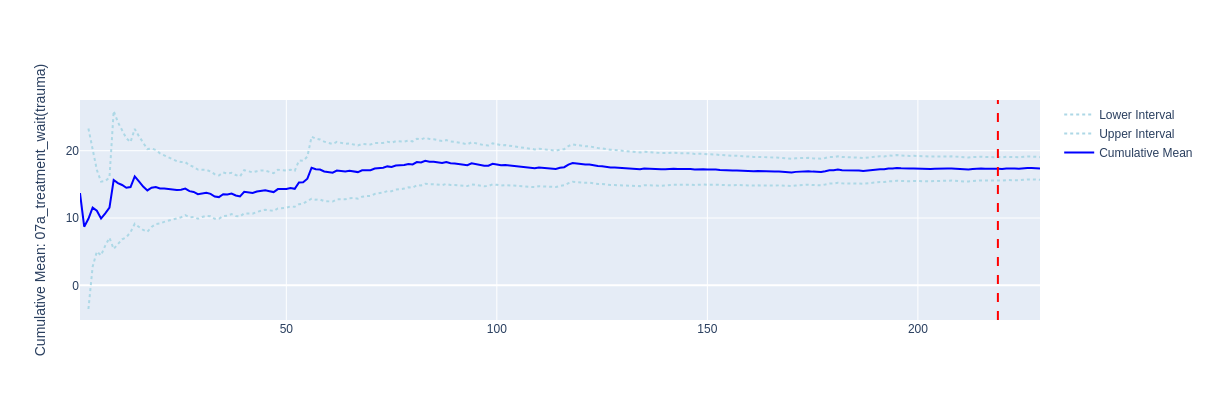

In [24]:
plotly_confidence_interval_method(
    n_reps, observer.summary_table(), metric_name="07a_treatment_wait(trauma)"
)

## Loop across all metrics

Note this is inefficient as we are repeated running the same replications for different measures.

In [25]:
half_width_precision = 0.1
scenario = Scenario()
all_metrics = results.columns.tolist()
selected = {}

for metric in all_metrics:

    analyser = ReplicationsAlgorithm(half_width_precision=half_width_precision)
    selected[metric] = analyser.select(scenario, metric)
pd.Series(selected)

00_arrivals                         3
01a_triage_wait                   145
01b_triage_util                     4
02a_registration_wait              16
02b_registration_util               3
03a_examination_wait               51
03b_examination_util                3
04a_treatment_wait(non_trauma)     19
04b_treatment_util(non_trauma)      3
05_total_time(non-trauma)           5
06a_trauma_wait                    96
06b_trauma_util                     6
07a_treatment_wait(trauma)        219
07b_treatment_util(trauma)         14
08_total_time(trauma)              24
09_throughput                       3
dtype: int64

## Generalising the ReplicationsAnalyser for any model

Each Python simulation model will have a slightly difference interface and hence the line of code the runs a single replication of the model will not work in the class. Rather than updating the code of the class each time we want to use it we can use the **Adapter Pattern** from Object Orientated Design principles.  This means we create a "wrapper" class around the model with a known fixed **interface**.

To formalise Python's **duck typing** feature we will create an `Protocol` class called `ReplicationsAlgorithmModelAdapter` that has specifies an inteface method called `single_run`. We will then create a concrete implementation called  `TreatSimAdapter` that adheres to the `ReplicationsAlgorithmModelAdapter` interface and pass this to the `select` method of a modified `ReplicationsAlgorithm`. 

#### Additional imports for typing

In [26]:
from typing import Protocol, runtime_checkable
from collections.abc import Callable

In [27]:
@runtime_checkable
class ReplicationsAlgorithmModelAdapter(Protocol):
    """
    Adapter pattern for the "Replications Algorithm".

    All models that use ReplicationsAlgorithm must provide a
    single_run(replication_number) interface.
    """

    def single_run(self, replication_number: int) -> float:
        """
        Perform a unique replication of the model. Return a performance measure
        """
        pass

In [28]:
class TreatSimAdapter:
    """
    treat-sim single_run interface adapted for the ReplicationsAlgorithm.
    """

    def __init__(
        self,
        scenario: Scenario,
        metric: str,
        single_run_func: Callable,
        run_length: Optional[float] = 1140.0,
    ):
        """
        Paramerters:
        ------------
        scenario: Scenario
            The experiment and parameter class for treat-sim

        metric: str
            The metric to output

        single_run_func: Callable
            The single run function that is being adapted

        run_length: float, optional (default = 1140)
            The run_length for the model

        """
        self.scenario = scenario
        self.metric = metric
        self.single_run_func = single_run_func
        self.run_length = run_length

    def single_run(self, replication_number: int) -> float:
        return self.single_run_func(
            self.scenario,
            rc_period=self.run_length,
            random_no_set=replication_number,
        )[self.metric].iloc[0]

In [29]:
ts_model = TreatSimAdapter(scenario, "01a_triage_wait", single_run)
ts_model.single_run(1)

np.float64(57.120114285877285)

We made our Protocol runtime checkable so we can valid the interface of any models passed to the replication analyser

In [30]:
isinstance(ts_model, ReplicationsAlgorithmModelAdapter)

True

In [31]:
INTERFACE_ERROR = (
    "Parameter 'model' must implement "
    + "ReplicationsAlgorithmModelAdapter interface. i.e. "
    + "single_run(replication_no: int) -> float"
)

In [32]:
class ReplicationsAlgorithm:
    """
    An implementation of the "Replications Algorithm" from
    Hoad, Robinson, & Davies (2010).

    Given a model's performance measure, and a user set CI half width precision
    automatically select the number of replications.

    Combines the "confidence intervals" method with a sequential look-ahead
    procedure to determine if a desired precision in CI is maintained when
    achieved.

    Note only works with a single performance measure

    Sources:
    -------

    Please cite the authors of the algorthim if you use it in your work.

    Hoad, Robinson, & Davies (2010). Automated selection of the number of
    replications for a discrete-event simulation. Journal of the Operational
    Research Society. https://www.jstor.org/stable/40926090

    the code is MIT so please use, but also please cite our respository!
    """

    def __init__(
        self,
        alpha: Optional[float] = 0.05,
        half_width_precision: Optional[float] = 0.1,
        initial_replications: Optional[int] = 3,
        look_ahead: Optional[int] = 5,
        replication_budget: Optional[float] = 1000,
        verbose: Optional[bool] = False,
        observer: Optional[ReplicationObserver] = None,
    ):
        """
        Initiatise the replications algorithm

        Parameters:
        ----------
        alpha: float, optional (default = 0.05)
            Used to construct the 100(1-alpha) CI

        half_width_precision: float, optional (default = 0.1)
            The target half width precision for the algorithm
            % deviation of the interval from mean.

        look_ahead: int, optional (default = 5)
            Recommended no. replications to look ahead to assess stability
            of precision.  When the number of replications n <= 100 the
            value of look ahead is used. When n > 100 then
            look_ahead / 100 * max(n, 100) is used.

        replication_budget: int, optional (default = 1000)
            A hard limit on the number of replications. Use for larger models
            where replication runtime is a constraint.

        verbose: bool, optional (default=False)
            Display the current replication number while running

        observer: ReplicationObserver, optional (default=None)
            Include an observer object to track how statistics change as the
            algorithm runs. For example ReplicationTabuliser to return a table
            equivalent to confidence_interval_method.
        """
        self.alpha = alpha
        self.half_width_precision = half_width_precision
        self.initial_replications = initial_replications
        # look ahead when n < 100
        self.look_ahead = look_ahead

        # hard constraint will terminate alg...
        self.replication_budget = replication_budget

        # show current replication no.
        self.verbose = verbose

        # current replication number
        self.n = self.initial_replications
        # Nsol
        self._n_solution = self.replication_budget

        self.observer = observer

    def _klimit(self) -> int:
        """
        Return the current look ahead.
        if n <= 100 then return kLimit.  If n > 100 then compute kLimit
        as fraction of n
        """
        return int((self.look_ahead / 100) * max(self.n, 100))

    def select(self, model: ReplicationsAlgorithmModelAdapter) -> int:

        if not isinstance(model, ReplicationsAlgorithmModelAdapter):
            raise ValueError(INTERFACE_ERROR)

        converged = False

        # run initial replications of model
        x_i = [
            model.single_run(rep) for rep in range(self.initial_replications)
        ]

        # initialise running mean and std dev
        self.stats = OnlineStatistics(
            data=np.array(x_i), alpha=self.alpha, observer=self.observer
        )

        while not converged and self.n <= self.replication_budget:
            if self.n > self.initial_replications:
                # update X_n and d_req
                self.stats.update(x_i)

            # precision achieved?
            if self.stats.deviation <= self.half_width_precision:

                # store current solution
                self._n_solution = self.n
                converged = True

                if self._klimit() > 0:
                    k = 1

                    # look ahead loop
                    while converged and k <= self._klimit():
                        if self.verbose:
                            print(f"{self.n+k}", end=", ")

                        # simulate replication n + k
                        x_i = model.single_run(self.n + k - 1)

                        # update X_n and d_req
                        self.stats.update(x_i)

                        # check new precision
                        if self.stats.deviation > self.half_width_precision:
                            # precision not maintained
                            converged = False
                            self.n += k
                        else:
                            k += 1

                # terminate if precision maintained over lookahead
                if converged:
                    return self._n_solution

            # precision not achieved/maintained so simulate another replication
            self.n += 1
            if self.verbose:
                print(f"{self.n}", end=", ")
            x_i = model.single_run(self.n - 1)

        # if code gets to here then no solution found within budget.
        warnings.warn(
            f"Algorithm did not converge for '{metric}'. "
            + "Returning replication budget as solution"
        )
        return self._n_solution

In [33]:
# a default scenario
scenario = Scenario()
ts_model = TreatSimAdapter(scenario, "01a_triage_wait", single_run)

analyser = ReplicationsAlgorithm(verbose=False)
n_replications = analyser.select(ts_model)
n_replications

145

## Example adapting another model

We will also employ the replications algorithm with a simple call centre simulation model. This is in the local python package `CallCentreSim`. This model has a warm-up period option as it is non-terminating. We will include it here to demonstrate that the approach works.

In [34]:
from callcentresim.model import (
    single_run as single_run_cc, 
    Experiment
)

In [35]:
cs_experiment = Experiment()
cs_results = single_run_cc(cs_experiment, rep=0, wu_period=500)
cs_results

{'01_mean_waiting_time': np.float64(2.3338781077765987),
 '02_operator_util': 93.19428726501377,
 '03_operator_queue_length': 3.8736787828971964,
 '04_mean_nurse_waiting_time': np.float64(63.14224868116588),
 '05_nurse_util': 99.93320374133907,
 '06_nurse_queue_length': 43.21349163157659}

The model has a different interface to `treat-sim` so we need a new adapter. We will follow the interface we specified for `single_run`

In [36]:
class CallCentreSimAdapter:
    """
    callcentresim single_run interface adapted for the ReplicationsAlgorithm.
    """

    def __init__(self, experiment, metric, single_run_func, wu_period):
        self.experiment = experiment
        self.metric = metric
        self.single_run_func = single_run_func
        self.wu_period = wu_period

    def single_run(self, replication_number):
        results = self.single_run_func(
            self.experiment, rep=replication_number, wu_period=self.wu_period
        )
        return results[self.metric]

In [37]:
half_width_precision = 0.1
experiment = Experiment()
all_metrics = list(cs_results.keys())
selected = {}

for metric in all_metrics:
    model_adapter = CallCentreSimAdapter(
        experiment, metric, single_run_cc, wu_period=50
    )
    analyser = ReplicationsAlgorithm(half_width_precision=half_width_precision)
    selected[metric] = analyser.select(model_adapter)
pd.Series(selected)

01_mean_waiting_time          137
02_operator_util                3
03_operator_queue_length      145
04_mean_nurse_waiting_time    152
05_nurse_util                   3
06_nurse_queue_length         164
dtype: int64

## `sim-tools` implementation

The package `sim-tools` contains an efficient implementation of the Replications Algorithm. It is able to process multiple performance measures in a single pass and saves computational time.

For more information see the [official sim-tools documentation](https://sim-tools.github.io/sim-tools/user-guide/output_analysis/automated_reps.html)